# ResNet18 — so sánh 4 Agent

**ONNX Runtime CPU · ONNX Runtime GPU · PyTorch CPU · PyTorch GPU**

Notebook đọc report thật trong `reports/`, dùng logical model `resnet18_v1`. Chọn kernel Python của `venv` rồi **Run All**. Mặc định chỉ đọc report, không benchmark lại.

**Lưu ý về phép đo:** ONNX dùng PRoof (thời gian `model_run` từ ONNX Runtime profiling); PyTorch dùng BasicProfiler (thời gian gọi `predict`, gồm chuyển input/output giữa host và device). Số lần warmup/đo cũng khác. Các biểu đồ mô tả kết quả đã thu thập, không phải bằng chứng framework nào nhanh hơn trong cùng điều kiện đo. `weights: null` là weights khởi tạo, không dùng để đánh giá accuracy.

In [1]:
from pathlib import Path
import json
import sys
import subprocess
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "agent/agent.py").is_file() and (p / "manifests/resnet18.yaml").is_file()), None)
if ROOT is None:
    raise RuntimeError("Hãy mở notebook trong repo XLDL2 hoặc thư mục con của repo.")
CONFIGS = [
    ("onnx_cpu", "ONNX CPU", "onnxruntime", "cpu", "PRoof"),
    ("onnx_gpu", "ONNX GPU", "onnxruntime", "gpu", "PRoof"),
    ("pytorch_cpu", "PyTorch CPU", "pytorch", "cpu", "BasicProfiler"),
    ("pytorch_gpu", "PyTorch GPU", "pytorch", "gpu", "BasicProfiler"),
]
plt.style.use("seaborn-v0_8-whitegrid")
print("Repo:", ROOT)
print("Kernel:", sys.executable)

Repo: e:\DHBKDN\HK7\XLDL\Proof\XLDL2
Kernel: c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\python.exe


## 1. Chạy lại benchmark (tùy chọn)

Đổi `RERUN = True` để chạy tuần tự bốn CLI, mỗi Agent trong **tiến trình riêng**, tránh xung đột DLL CUDA giữa PyTorch và ONNX Runtime. Report sẽ được cập nhật. Nếu có lỗi, notebook dừng thay vì dùng lại report cũ và báo thành công nhầm.

In [2]:
RERUN = False
if RERUN:
    python = ROOT / "venv/Scripts/python.exe"
    if not python.is_file():
        python = Path(sys.executable)
    for key, label, *_ in CONFIGS:
        command = [str(python), str(ROOT / "agent/agent.py"),
                   "--agent-config", f"configs/agent_{key}.yaml",
                   "--manifest", "manifests/resnet18.yaml",
                   "--report-path", f"reports/resnet18_{key}.json"]
        result = subprocess.run(command, cwd=ROOT, capture_output=True)
        print(result.stdout.decode("utf-8", errors="replace").replace("\x00", ""))
        if result.returncode:
            raise RuntimeError(f"{label} failed (exit {result.returncode}):\n" +
                               result.stderr.decode("utf-8", errors="replace").replace("\x00", ""))
else:
    print("Đọc report đã có; không chạy benchmark mới.")

Đọc report đã có; không chạy benchmark mới.


## 2. Chuẩn hóa report và kiểm tra nguồn model

PRoof lưu latency bằng **giây**; BasicProfiler lưu bằng **mili giây**. Throughput tính theo `batch_size × 1000 / latency_ms`, là tốc độ suy ra từ latency tuần tự, không phải benchmark concurrent throughput. Thời gian sửa file cho biết report được cập nhật lúc nào; bốn kết quả có thể được đo ở các thời điểm khác nhau.

In [3]:
rows, provenance, raw = [], [], {}
for key, label, backend, device, profiler in CONFIGS:
    path = ROOT / "reports" / f"resnet18_{key}.json"
    if not path.is_file():
        raise FileNotFoundError(f"Thiếu {path}; bật RERUN hoặc chạy CLI tương ứng.")
    report = json.loads(path.read_text(encoding="utf-8"))
    raw[key] = report
    for field in ("model_id", "source_framework", "artifact_format", "artifact_path", "generated_from"):
        if field not in report:
            raise ValueError(f"{label}: thiếu metadata {field}; cần chạy lại report.")
    if backend == "onnxruntime":
        results = report["model"]["bench"]["results"]
        if len(results) != 1:
            raise ValueError("Notebook này yêu cầu mỗi report có một batch size.")
        result = next(iter(results.values()))
        batch = result["batch_size"]
        latency = float(result["time_avg"]) * 1000
        samples = len(result["times"])
        scope = "ORT model_run events"
        std = float(result["time_std"]) * 1000
    else:
        batch = report["batch_size"]
        latency = float(report["performance"]["avg_latency_ms"])
        samples = report["benchmark_iterations"]
        scope = report["measurement_scope"]
        std = np.nan  # BasicProfiler chưa lưu phân phối latency; không tự suy đoán.
    if not np.isfinite(latency) or latency <= 0:
        raise ValueError(f"Latency không hợp lệ: {label}")
    rows.append(dict(agent=label, backend=backend, device=device, profiler=profiler,
                     batch_size=batch, latency_ms=latency, throughput_samples_s=batch*1000/latency,
                     measured_iterations=samples, std_ms=std, scope=scope,
                     report_updated=datetime.fromtimestamp(path.stat().st_mtime).astimezone().isoformat(timespec="seconds")))
    provenance.append(dict(agent=label, model_id=report["model_id"],
                           source_framework=report["source_framework"],
                           artifact_format=report["artifact_format"], artifact_path=report["artifact_path"],
                           generated_from=report["generated_from"]))

df = pd.DataFrame(rows).set_index("agent")
source_df = pd.DataFrame(provenance).set_index("agent")
assert source_df.model_id.nunique() == 1, "Các report không cùng logical model."
assert source_df.source_framework.eq("pytorch").all()
assert df.batch_size.nunique() == 1, "Các report có batch size khác nhau."
assert source_df.loc["ONNX CPU", "artifact_path"] == source_df.loc["ONNX GPU", "artifact_path"]
assert source_df.loc["PyTorch CPU", "artifact_path"] == source_df.loc["PyTorch GPU", "artifact_path"]
assert source_df.loc[["ONNX CPU", "ONNX GPU"], "generated_from"].eq(source_df.loc["PyTorch CPU", "artifact_path"]).all()
display(source_df)
display(df[["profiler", "batch_size", "latency_ms", "throughput_samples_s", "measured_iterations", "std_ms"]].round(4))
display(df[["scope", "report_updated"]])

,model_id,source_framework,artifact_format,artifact_path,generated_from
agent,,,,,
ONNX CPU,resnet18_v1,pytorch,onnx,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...
ONNX GPU,resnet18_v1,pytorch,onnx,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...
PyTorch CPU,resnet18_v1,pytorch,pytorch,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...,None
PyTorch GPU,resnet18_v1,pytorch,pytorch,E:\DHBKDN\HK7\XLDL\Proof\XLDL2\models\resnet18...,None


,profiler,batch_size,latency_ms,throughput_samples_s,measured_iterations,std_ms
agent,,,,,,
ONNX CPU,PRoof,1,9.8838,101.1757,10,2.9935
ONNX GPU,PRoof,1,3.0492,327.9549,10,0.4718
PyTorch CPU,BasicProfiler,1,18.0149,55.5095,50,NaN
PyTorch GPU,BasicProfiler,1,3.3702,296.7194,50,NaN


,scope,report_updated
agent,,
ONNX CPU,ORT model_run events,2026-10-02T22:58:59+07:00
ONNX GPU,ORT model_run events,2026-10-02T23:04:55+07:00
PyTorch CPU,predict API including input conversion and out...,2026-10-02T22:58:48+07:00
PyTorch GPU,predict API including input conversion and out...,2026-10-02T22:58:55+07:00


## 3. Latency và throughput

Latency thấp hơn là tốt hơn; throughput cao hơn là tốt hơn. Không đặt error bar cho PyTorch vì report không lưu từng mẫu đo.

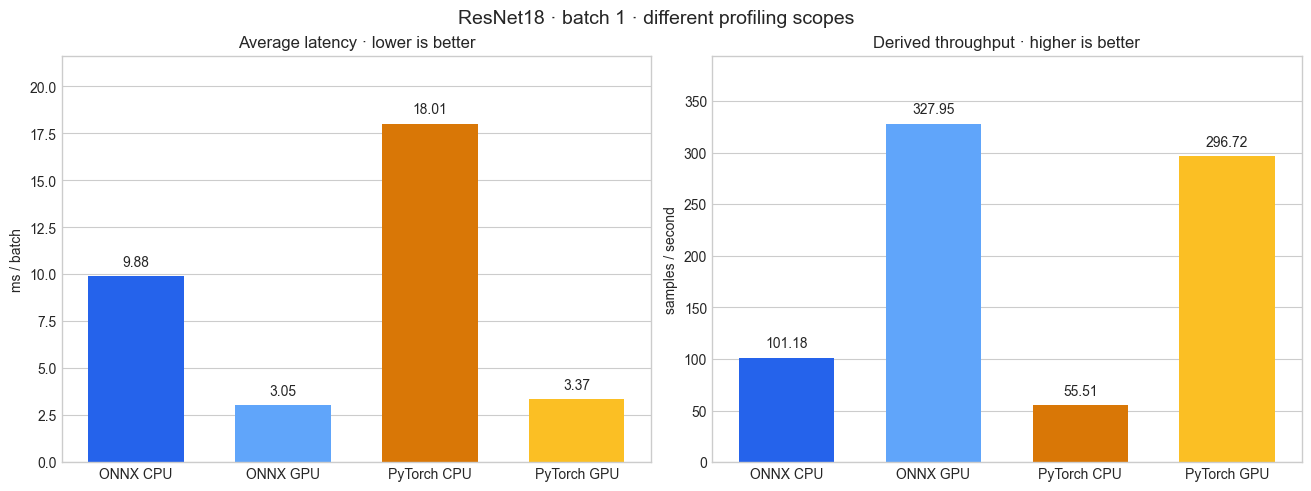

In [4]:
colors = ["#2563eb", "#60a5fa", "#d97706", "#fbbf24"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
for ax, field, title, unit in [
    (axes[0], "latency_ms", "Average latency · lower is better", "ms / batch"),
    (axes[1], "throughput_samples_s", "Derived throughput · higher is better", "samples / second"),
]:
    bars = ax.bar(df.index, df[field], color=colors, width=0.65)
    ax.bar_label(bars, fmt="%.2f", padding=5)
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.set_ylim(0, df[field].max()*1.2)
    ax.grid(axis="x", visible=False)
fig.suptitle(f"ResNet18 · batch {int(df.batch_size.iloc[0])} · different profiling scopes", fontsize=14)
plt.show()

## 4. GPU so với CPU trong từng backend

`speedup = latency_CPU / latency_GPU`. Tỷ số > 1 nghĩa là GPU nhanh hơn trong các report này. Đây là kết quả của một lượt benchmark, không phải bảo đảm tốc độ trên mọi workload.

In [5]:
speedups = []
for backend, group in df.groupby("backend", sort=False):
    times = group.set_index("device").latency_ms
    speedups.append({"backend": backend, "CPU_ms": times["cpu"], "GPU_ms": times["gpu"],
                     "GPU_speedup": times["cpu"] / times["gpu"]})
speedup_df = pd.DataFrame(speedups).set_index("backend")
display(speedup_df.round(3))
for backend, row in speedup_df.iterrows():
    print(f"{backend}: GPU speedup = {row.GPU_speedup:.2f}x (CPU {row.CPU_ms:.2f} ms; GPU {row.GPU_ms:.2f} ms)")

,CPU_ms,GPU_ms,GPU_speedup
backend,,,
onnxruntime,9.884,3.049,3.241
pytorch,18.015,3.370,5.345


onnxruntime: GPU speedup = 3.24x (CPU 9.88 ms; GPU 3.05 ms)
pytorch: GPU speedup = 5.35x (CPU 18.01 ms; GPU 3.37 ms)


## 5. Kiểm chứng artifact PyTorch → ONNX

Metadata bên cạnh ONNX ghi checksum của source weights và kết quả validation tại lúc export. Đối chiếu checksum với file hiện tại giúp xác nhận lineage artifact; report hiện chưa lưu checksum tại thời điểm đo nên không thể chứng minh tuyệt đối một report cũ đã dùng đúng phiên bản file hiện tại.

In [6]:
import hashlib

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024*1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

artifact_root = ROOT / "models" / source_df.model_id.iloc[0]
pth = artifact_root / "pytorch/resnet18.pth"
onnx = artifact_root / "onnx/resnet18.onnx"
metadata = json.loads(onnx.with_suffix(".onnx.json").read_text(encoding="utf-8"))
assert sha256(pth) == metadata["source_sha256"], "Weights nguồn đã thay đổi."
assert sha256(onnx) == metadata["sha256"], "ONNX artifact đã thay đổi."
print("Checksum source weights và ONNX artifact: PASS")
print("Validation tolerance:", {k: metadata["validation"][k] for k in ("rtol", "atol")})
display(pd.DataFrame(metadata["validation"]["checks"]))

Checksum source weights và ONNX artifact: PASS
Validation tolerance: {'rtol': 0.001, 'atol': 0.0001}


,batch_size,max_abs_error
0,1,0.000004
1,2,0.000003


## Cách đọc kết quả

- Bốn cấu hình dùng chung logical model và source weights theo metadata report.
- Chỉ so sánh các số đo với đúng phạm vi đo được mô tả phía trên. PRoof và BasicProfiler không có cùng overhead hoặc số lượt chạy.
- PyTorch GPU có đồng bộ CUDA trước/sau timing; thời gian bao gồm chuyển dữ liệu. Không suy ra kernel-only latency từ số này.
- Muốn so sánh công bằng giữa framework: cần một benchmark chung với cùng input, warmup, số lượt đo, đồng bộ, thread count và chính sách chuyển dữ liệu. Notebook này chưa thay đổi profiling engine.
- Chạy riêng từng CLI khi cần đo lại; không khởi tạo đồng thời PyTorch CUDA 13 và ONNX CUDA 12 trong cùng kernel.